# Data protocol (read before re-running)

**This notebook must be re-run top to bottom.** Any outputs still stored below were
produced by the earlier version, which trained, selected and rewarded on the test
set; those numbers are optimistically biased and should not be cited.

Splits used now:

| Split | Size | Used for |
|---|---|---|
| `train_loader` | 45,000 (CIFAR-10 train) | all weight updates |
| `val_loader` / `small_val_loader` | 5,000 / 1,000 (CIFAR-10 train, held out) | epoch selection, layer sensitivity, RL reward |
| `test_loader` | 10,000 (CIFAR-10 test) | one final measurement per reported method |

The PPO training environment is constructed with `test_loader=None`, so the agent
cannot be shaped by the test set even indirectly.

Imports

In [1]:
import os
import copy
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.utils.prune as prune

import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Subset

import gymnasium as gym
from gymnasium import spaces

from stable_baselines3 import PPO
from stable_baselines3.common.env_checker import check_env

In [2]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

os.makedirs("../checkpoints", exist_ok=True)
os.makedirs("../results", exist_ok=True)

Device: cpu


Dataset

In [ ]:
# ---------------------------------------------------------------------------
# Data splits (no test-set leakage)
#
#   train_dataset : 45,000 CIFAR-10 training images -> all weight updates
#   val_dataset   :  5,000 CIFAR-10 training images -> epoch selection,
#                                                      RL reward, sensitivity
#   test_dataset  : 10,000 CIFAR-10 test images     -> touched ONCE, only for
#                                                      the final reported numbers
#
# Nothing that influences training or model selection is ever measured on
# test_dataset.
# ---------------------------------------------------------------------------

VAL_SIZE = 5000          # held-out validation images taken from the train split
RL_PROBE_SIZE = 1000     # small validation subset used as the RL reward signal
RL_FINETUNE_SIZE = 5000  # small training subset used for in-episode fine-tuning

transform_train = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=(0.4914, 0.4822, 0.4465),
        std=(0.2470, 0.2435, 0.2616)
    )
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        mean=(0.4914, 0.4822, 0.4465),
        std=(0.2470, 0.2435, 0.2616)
    )
])

# Same 50,000 images, two views: augmented (for training) and plain (for evaluation).
cifar_train_augmented = torchvision.datasets.CIFAR10(
    root="../data",
    train=True,
    download=True,
    transform=transform_train
)

cifar_train_plain = torchvision.datasets.CIFAR10(
    root="../data",
    train=True,
    download=True,
    transform=transform_test
)

split_generator = torch.Generator().manual_seed(SEED)
permuted_indices = torch.randperm(len(cifar_train_augmented), generator=split_generator).tolist()

train_indices = permuted_indices[:-VAL_SIZE]
val_indices = permuted_indices[-VAL_SIZE:]

assert not (set(train_indices) & set(val_indices)), "train/val split overlaps"

train_dataset = Subset(cifar_train_augmented, train_indices)
val_dataset = Subset(cifar_train_plain, val_indices)  # evaluation view: no random crop/flip

test_dataset = torchvision.datasets.CIFAR10(
    root="../data",
    train=False,
    download=True,
    transform=transform_test
)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=128, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False, num_workers=0)

# Fast loaders used inside the RL loop.
# The reward is measured on held-out validation images, while the in-episode
# fine-tuning only ever sees training images, so the two never overlap.
small_val_dataset = Subset(cifar_train_plain, val_indices[:RL_PROBE_SIZE])
small_val_loader = DataLoader(small_val_dataset, batch_size=128, shuffle=False, num_workers=0)

rl_finetune_dataset = Subset(cifar_train_augmented, train_indices[:RL_FINETUNE_SIZE])
rl_finetune_loader = DataLoader(rl_finetune_dataset, batch_size=128, shuffle=True, num_workers=0)

print("train:", len(train_dataset), "| val:", len(val_dataset), "| test:", len(test_dataset))
print("RL reward probe:", len(small_val_dataset), "| RL fine-tune subset:", len(rl_finetune_dataset))

CNN Model

In [43]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 256),
            nn.ReLU(),
            nn.Linear(256, 10)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

Train / Evaluate / Fine-tune

In [44]:
def evaluate_model(model, loader, device, print_result=True):
    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    acc = 100 * correct / total

    if print_result:
        print(f"Accuracy: {acc:.2f}%")

    return acc

In [ ]:
def train_model(model, train_loader, val_loader, device, epochs=15, lr=0.001):
    """Train and keep the epoch with the best HELD-OUT VALIDATION accuracy.

    Model selection never looks at the test set, so the accuracy this returns
    is a validation figure. Report test accuracy separately, once, on the
    model this function returns.
    """
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    best_val_acc = 0.0
    best_state = None

    for epoch in range(epochs):
        model.train()

        total_loss = 0.0
        correct = 0
        total = 0

        for images, labels in train_loader:
            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            total_loss += loss.item()

            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        train_acc = 100 * correct / total
        val_acc = evaluate_model(model, val_loader, device, print_result=False)

        print(
            f"Epoch [{epoch+1}/{epochs}] "
            f"Loss: {total_loss / len(train_loader):.4f} | "
            f"Train Acc: {train_acc:.2f}% | "
            f"Val Acc: {val_acc:.2f}%"
        )

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state = copy.deepcopy(model.state_dict())

    model.load_state_dict(best_state)

    return model, best_val_acc

In [ ]:
def finetune_model(model, train_loader, val_loader, device, epochs=3, lr=0.0001):
    """Fine-tune and keep the epoch with the best HELD-OUT VALIDATION accuracy.

    Same contract as train_model: the returned accuracy is a validation figure,
    used for selection and for the RL reward. Test accuracy is measured
    separately, once, on the returned model.
    """
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    best_val_acc = evaluate_model(model, val_loader, device, print_result=False)
    best_state = copy.deepcopy(model.state_dict())

    for epoch in range(epochs):
        model.train()

        for images, labels in train_loader:
            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

        val_acc = evaluate_model(model, val_loader, device, print_result=False)

        print(f"Fine-tune Epoch [{epoch+1}/{epochs}] Val Acc: {val_acc:.2f}%")

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state = copy.deepcopy(model.state_dict())

    model.load_state_dict(best_state)

    return model, best_val_acc

Train Baseline

In [ ]:
baseline_model = SimpleCNN().to(device)

baseline_model, baseline_val_accuracy = train_model(
    model=baseline_model,
    train_loader=train_loader,
    val_loader=val_loader,
    device=device,
    epochs=15,
    lr=0.001
)

# Single, final measurement on the test set. Nothing above depended on it.
baseline_accuracy = evaluate_model(baseline_model, test_loader, device, print_result=False)

print(f"Baseline validation accuracy (used for selection): {baseline_val_accuracy:.2f}%")
print(f"Baseline test accuracy (reported): {baseline_accuracy:.2f}%")

torch.save(baseline_model.state_dict(), "../checkpoints/baseline_clean.pth")

In [ ]:
baseline_model = SimpleCNN().to(device)
baseline_model.load_state_dict(torch.load("../checkpoints/baseline_clean.pth", map_location=device))
baseline_model.eval()

baseline_val_accuracy = evaluate_model(baseline_model, val_loader, device, print_result=False)
baseline_accuracy = evaluate_model(baseline_model, test_loader, device, print_result=False)

print(f"Reloaded baseline | Val: {baseline_val_accuracy:.2f}% | Test: {baseline_accuracy:.2f}%")

Fine-tune Baseline with Same Settings

In [ ]:
baseline_ft_model = copy.deepcopy(baseline_model)

baseline_ft_model, baseline_finetuned_val_accuracy = finetune_model(
    model=baseline_ft_model,
    train_loader=train_loader,
    val_loader=val_loader,
    device=device,
    epochs=3,
    lr=0.0001
)

# Single, final measurement on the test set.
baseline_finetuned_accuracy = evaluate_model(baseline_ft_model, test_loader, device, print_result=False)

print(f"Baseline             | Val: {baseline_val_accuracy:.2f}% | Test: {baseline_accuracy:.2f}%")
print(f"Baseline + fine-tune | Val: {baseline_finetuned_val_accuracy:.2f}% | Test: {baseline_finetuned_accuracy:.2f}%")
print(f"Fine-tune gain (test): {baseline_finetuned_accuracy - baseline_accuracy:+.2f} pp")

torch.save(baseline_ft_model.state_dict(), "../checkpoints/baseline_finetuned.pth")

Pruning Utilities

In [10]:
def get_prunable_layers(model):
    layers = []

    for name, module in model.named_modules():
        if isinstance(module, (nn.Conv2d, nn.Linear)):
            layers.append((name, module))

    return layers

In [11]:
prunable_layers_all = get_prunable_layers(baseline_model)

for i, (name, layer) in enumerate(prunable_layers_all):
    print(i, name, type(layer).__name__, layer.weight.numel())

0 features.0 Conv2d 864
1 features.3 Conv2d 18432
2 features.6 Conv2d 73728
3 classifier.1 Linear 524288
4 classifier.3 Linear 2560


In [12]:
prunable_layers_filtered = [
    (name, layer)
    for name, layer in prunable_layers_all
    if name != "classifier.3"
]

print("Filtered layers:")
for i, (name, layer) in enumerate(prunable_layers_filtered):
    print(i, name, type(layer).__name__, layer.weight.numel())

Filtered layers:
0 features.0 Conv2d 864
1 features.3 Conv2d 18432
2 features.6 Conv2d 73728
3 classifier.1 Linear 524288


In [13]:
def apply_layer_pruning_by_name_inplace(model, layer_name, amount):
    for name, module in model.named_modules():
        if name == layer_name and isinstance(module, (nn.Conv2d, nn.Linear)):
            prune.l1_unstructured(module, name="weight", amount=amount)
            return model

    raise ValueError(f"Layer not found: {layer_name}")

In [14]:
def calculate_sparsity(model):
    total = 0
    zeros = 0

    for module in model.modules():
        if isinstance(module, (nn.Conv2d, nn.Linear)):
            weight = module.weight
            total += weight.nelement()
            zeros += torch.sum(weight == 0).item()

    return 100 * zeros / total

Layer Sensitivity

In [15]:
def compute_layer_sensitivities(model, prunable_layers, loader, device, probe_amount=0.1):
    sensitivities = {}

    base_acc = evaluate_model(model, loader, device, print_result=False)
    print("Sensitivity baseline accuracy:", base_acc)

    for layer_name, _ in prunable_layers:
        temp_model = copy.deepcopy(model)

        temp_model = apply_layer_pruning_by_name_inplace(
            temp_model,
            layer_name,
            probe_amount
        ).to(device)

        pruned_acc = evaluate_model(temp_model, loader, device, print_result=False)
        drop = base_acc - pruned_acc

        sensitivities[layer_name] = drop

        print(f"{layer_name}: drop={drop:.4f}")

    return sensitivities

In [16]:
layer_sensitivities = compute_layer_sensitivities(
    model=baseline_model,
    prunable_layers=prunable_layers_filtered,
    loader=small_val_loader,
    device=device,
    probe_amount=0.1
)

Sensitivity baseline accuracy: 79.7
features.0: drop=0.4000
features.3: drop=0.0000
features.6: drop=0.0000
classifier.1: drop=0.0000


Action Space

In [17]:
ACTION_TO_PRUNE = {
    0: 0.0,
    1: 0.1,
    2: 0.2,
    3: 0.3,
    4: 0.4,
    5: 0.6
}

State Representation

In [18]:
MAX_PARAM_COUNT = max(
    layer.weight.numel()
    for _, layer in prunable_layers_all
)

In [19]:
def extract_layer_state(
    layer,
    layer_index,
    total_layers,
    cumulative_pruning,
    layer_name,
    layer_sensitivities
):
    weights = layer.weight.detach().cpu()

    return {
        "layer_index": layer_index,
        "total_layers": total_layers,
        "param_count": weights.numel(),
        "mean_abs_weight": weights.abs().mean().item(),
        "std_weight": weights.std().item(),
        "cumulative_pruning": cumulative_pruning,
        "sensitivity": layer_sensitivities.get(layer_name, 0.0)
    }

In [20]:
def state_to_vector(state):
    return np.array([
        state["layer_index"] / max(1, state["total_layers"] - 1),
        np.log1p(state["param_count"]),
        state["param_count"] / MAX_PARAM_COUNT,
        state["mean_abs_weight"],
        state["std_weight"],
        state["cumulative_pruning"],
        state["sensitivity"]
    ], dtype=np.float32)

Reward Function for Accuracy Above Baseline
This reward tries to push accuracy recovery through fine-tuning.

In [21]:
def compute_reward(final_accuracy, baseline_accuracy, sparsity, actions=None):
    acc_gain = final_accuracy - baseline_accuracy

    reward = 0.04 * sparsity

    if acc_gain >= 0:
        reward += 5.0 + acc_gain
    else:
        reward += acc_gain * 2.0

    if actions is not None:
        reward += 0.05 * len(set(actions))

    return reward

Gym Environment with Fine-tuning
Each final pruned model is fine-tuned before reward calculation.

In [ ]:
class CompressionEnvGymFineTune(gym.Env):
    """Prune layer-by-layer, fine-tune the finished model, reward on VALIDATION data.

    Data contract (this is what keeps the experiment honest):
      * finetune_loader -> training images only; the only data that touches weights.
      * eval_loader     -> held-out validation images; produces the reward.
      * test_loader     -> optional, and used for nothing but the final reported
                           number. Leave it as None for the PPO training env so
                           the agent can never be shaped by the test set.

    baseline_accuracy must be measured on eval_loader, so that the reward
    compares like with like.
    """

    def __init__(
        self,
        base_model,
        prunable_layers,
        baseline_accuracy,
        eval_loader,
        finetune_loader,
        device,
        layer_sensitivities,
        finetune_epochs=1,
        finetune_lr=0.0001,
        test_loader=None
    ):
        super().__init__()

        self.base_model = base_model
        self.prunable_layers_info = [
            (name, type(layer).__name__)
            for name, layer in prunable_layers
        ]

        self.total_layers = len(prunable_layers)
        self.baseline_accuracy = baseline_accuracy
        self.eval_loader = eval_loader
        self.finetune_loader = finetune_loader
        self.test_loader = test_loader
        self.device = device
        self.layer_sensitivities = layer_sensitivities

        self.finetune_epochs = finetune_epochs
        self.finetune_lr = finetune_lr

        self.action_space = spaces.Discrete(len(ACTION_TO_PRUNE))

        self.observation_space = spaces.Box(
            low=-np.inf,
            high=np.inf,
            shape=(7,),
            dtype=np.float32
        )

        self.current_model = None
        self.current_layer_index = 0
        self.cumulative_pruning = 0.0
        self.actions_taken = []

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)

        self.current_model = copy.deepcopy(self.base_model)
        self.current_layer_index = 0
        self.cumulative_pruning = 0.0
        self.actions_taken = []

        return self._get_state(), {}

    def _get_state(self):
        if self.current_layer_index >= self.total_layers:
            return np.zeros((7,), dtype=np.float32)

        layer_name = self.prunable_layers_info[self.current_layer_index][0]

        for name, module in self.current_model.named_modules():
            if name == layer_name:
                state = extract_layer_state(
                    layer=module,
                    layer_index=self.current_layer_index,
                    total_layers=self.total_layers,
                    cumulative_pruning=self.cumulative_pruning,
                    layer_name=name,
                    layer_sensitivities=self.layer_sensitivities
                )
                return state_to_vector(state)

        raise ValueError(f"Layer not found: {layer_name}")

    def step(self, action):
        action = int(action)

        prune_amount = ACTION_TO_PRUNE[action]
        layer_name = self.prunable_layers_info[self.current_layer_index][0]

        self.current_model = apply_layer_pruning_by_name_inplace(
            self.current_model,
            layer_name,
            prune_amount
        )

        self.actions_taken.append(action)
        self.cumulative_pruning += prune_amount
        self.current_layer_index += 1

        terminated = self.current_layer_index >= self.total_layers
        truncated = False

        if terminated:
            # IMPORTANT:
            # Do not deepcopy after pruning masks are attached.
            # Use the already-copied episode model.
            tuned_model = self.current_model

            # Fine-tunes on training images, selects the epoch on validation images.
            tuned_model, tuned_val_accuracy = finetune_model(
                model=tuned_model,
                train_loader=self.finetune_loader,
                val_loader=self.eval_loader,
                device=self.device,
                epochs=self.finetune_epochs,
                lr=self.finetune_lr
            )

            final_sparsity = calculate_sparsity(tuned_model)

            # Reward comes from validation accuracy only.
            reward = compute_reward(
                final_accuracy=tuned_val_accuracy,
                baseline_accuracy=self.baseline_accuracy,
                sparsity=final_sparsity,
                actions=self.actions_taken
            )

            # Final reporting only; stays None during PPO training.
            test_accuracy = None

            if self.test_loader is not None:
                test_accuracy = evaluate_model(
                    tuned_model,
                    self.test_loader,
                    self.device,
                    print_result=False
                )

            obs = np.zeros((7,), dtype=np.float32)

            info = {
                "val_accuracy": tuned_val_accuracy,
                "test_accuracy": test_accuracy,
                "final_sparsity": final_sparsity,
                "reward": reward,
                "actions": self.actions_taken
            }

        else:
            obs = self._get_state()
            reward = 0.0
            info = {
                "current_layer": layer_name,
                "prune_amount": prune_amount
            }

        return obs, reward, terminated, truncated, info

Check Environment

In [ ]:
# The reward threshold has to be measured on the same data the episode is scored
# on, otherwise "accuracy >= baseline" is comparing two different measurements.
baseline_small_val_accuracy = evaluate_model(
    baseline_model,
    small_val_loader,
    device,
    print_result=False
)

print(f"Baseline accuracy on the RL probe set: {baseline_small_val_accuracy:.2f}%")

train_env = CompressionEnvGymFineTune(
    base_model=baseline_model,
    prunable_layers=prunable_layers_filtered,
    baseline_accuracy=baseline_small_val_accuracy,
    eval_loader=small_val_loader,        # held-out validation images -> reward
    finetune_loader=rl_finetune_loader,  # training images only -> weight updates
    device=device,
    layer_sensitivities=layer_sensitivities,
    finetune_epochs=1,
    finetune_lr=0.0001,
    test_loader=None                     # the agent must never see the test set
)

obs, info = train_env.reset()
result = train_env.step(1)

print("Obs shape:", obs.shape)
print("Step len:", len(result))
print(result)

In [33]:
check_env(train_env, warn=True)
print("Environment check passed")

Fine-tune Epoch [1/1] Test Acc: 81.60%
Fine-tune Epoch [1/1] Test Acc: 51.80%
Environment check passed


PPO Training with Fine-tuning Env

In [ ]:
train_env = CompressionEnvGymFineTune(
    base_model=baseline_model,
    prunable_layers=prunable_layers_filtered,
    baseline_accuracy=baseline_small_val_accuracy,
    eval_loader=small_val_loader,
    finetune_loader=rl_finetune_loader,
    device=device,
    layer_sensitivities=layer_sensitivities,
    finetune_epochs=1,
    finetune_lr=0.0001,
    test_loader=None
)

agent = PPO(
    policy="MlpPolicy",
    env=train_env,
    verbose=1,
    learning_rate=0.0003,
    n_steps=32,
    batch_size=16,
    n_epochs=5,
    gamma=0.99,
    ent_coef=0.02,
    seed=SEED
)

agent.learn(total_timesteps=300)

Evaluation Env with Full Test Set

In [ ]:
# Evaluation env: fine-tunes on the full training split, selects the epoch on the
# full validation split, and reports one clean test number per method.
eval_env = CompressionEnvGymFineTune(
    base_model=baseline_model,
    prunable_layers=prunable_layers_filtered,
    baseline_accuracy=baseline_val_accuracy,
    eval_loader=val_loader,
    finetune_loader=train_loader,
    device=device,
    layer_sensitivities=layer_sensitivities,
    finetune_epochs=3,
    finetune_lr=0.0001,
    test_loader=test_loader
)

Evaluate Trained Agent

In [ ]:
def evaluate_trained_agent(agent, env, policy_name):
    obs, info = env.reset()

    done = False
    chosen_actions = []

    while not done:
        action, _ = agent.predict(obs, deterministic=True)
        action = int(action)

        chosen_actions.append(action)

        obs, reward, terminated, truncated, info = env.step(action)

        done = terminated or truncated

    result = {
        "Method": policy_name,
        "Actions": str(chosen_actions),
        "Val Accuracy (%)": info["val_accuracy"],
        "Test Accuracy (%)": info["test_accuracy"],
        "Sparsity (%)": info["final_sparsity"],
        "Reward": info["reward"]
    }

    print(result)
    return result

In [37]:
ppo_finetune_result = evaluate_trained_agent(
    agent=agent,
    env=eval_env,
    policy_name="PPO_FineTune"
)

ppo_finetune_result

Fine-tune Epoch [1/3] Test Acc: 80.88%
Fine-tune Epoch [2/3] Test Acc: 81.12%
Fine-tune Epoch [3/3] Test Acc: 81.33%
{'Method': 'PPO_FineTune', 'Actions': '[2, 2, 2, 2]', 'Accuracy (%)': 81.33, 'Sparsity (%)': 19.917499096587683, 'Reward': 7.606699963863512}


{'Method': 'PPO_FineTune',
 'Actions': '[2, 2, 2, 2]',
 'Accuracy (%)': 81.33,
 'Sparsity (%)': 19.917499096587683,
 'Reward': 7.606699963863512}

Manual Baselines with Fine-tuning

In [ ]:
def run_fixed_policy_finetune(policy, policy_name):
    env = CompressionEnvGymFineTune(
        base_model=baseline_model,
        prunable_layers=prunable_layers_filtered,
        baseline_accuracy=baseline_val_accuracy,
        eval_loader=val_loader,
        finetune_loader=train_loader,
        device=device,
        layer_sensitivities=layer_sensitivities,
        finetune_epochs=3,
        finetune_lr=0.0001,
        test_loader=test_loader
    )

    obs, info = env.reset()
    done = False
    step_idx = 0

    while not done:
        action = policy[step_idx]

        obs, reward, terminated, truncated, info = env.step(action)

        step_idx += 1
        done = terminated or truncated

    result = {
        "Method": policy_name,
        "Actions": str(policy),
        "Val Accuracy (%)": info["val_accuracy"],
        "Test Accuracy (%)": info["test_accuracy"],
        "Sparsity (%)": info["final_sparsity"],
        "Reward": info["reward"]
    }

    print(result)
    return result

In [39]:
manual_ft_results = []

manual_ft_results.append(run_fixed_policy_finetune([1, 1, 1, 1], "FT Uniform 10%"))
manual_ft_results.append(run_fixed_policy_finetune([2, 2, 2, 2], "FT Uniform 20%"))
manual_ft_results.append(run_fixed_policy_finetune([4, 4, 4, 4], "FT Uniform 40%"))
manual_ft_results.append(run_fixed_policy_finetune([5, 5, 5, 5], "FT Uniform 60%"))

Fine-tune Epoch [1/3] Test Acc: 81.08%
Fine-tune Epoch [2/3] Test Acc: 80.81%
Fine-tune Epoch [3/3] Test Acc: 81.01%
{'Method': 'FT Uniform 10%', 'Actions': '[1, 1, 1, 1]', 'Accuracy (%)': 81.08, 'Sparsity (%)': 9.958668886479789, 'Reward': 6.958346755459196}
Fine-tune Epoch [1/3] Test Acc: 80.81%
Fine-tune Epoch [2/3] Test Acc: 81.03%
Fine-tune Epoch [3/3] Test Acc: 80.95%
{'Method': 'FT Uniform 20%', 'Actions': '[2, 2, 2, 2]', 'Accuracy (%)': 81.03, 'Sparsity (%)': 19.917499096587683, 'Reward': 7.306699963863515}
Fine-tune Epoch [1/3] Test Acc: 80.37%
Fine-tune Epoch [2/3] Test Acc: 80.53%
Fine-tune Epoch [3/3] Test Acc: 80.77%
{'Method': 'FT Uniform 40%', 'Actions': '[4, 4, 4, 4]', 'Accuracy (%)': 80.77, 'Sparsity (%)': 39.83483686954726, 'Reward': 7.843393474781894}
Fine-tune Epoch [1/3] Test Acc: 78.29%
Fine-tune Epoch [2/3] Test Acc: 79.53%
Fine-tune Epoch [3/3] Test Acc: 79.86%
{'Method': 'FT Uniform 60%', 'Actions': '[5, 5, 5, 5]', 'Accuracy (%)': 79.86, 'Sparsity (%)': 59.7521

Final Comparison

In [ ]:
baseline_row = {
    "Method": "Baseline",
    "Actions": "-",
    "Val Accuracy (%)": baseline_val_accuracy,
    "Test Accuracy (%)": baseline_accuracy,
    "Sparsity (%)": 0.0,
    "Reward": compute_reward(
        final_accuracy=baseline_val_accuracy,
        baseline_accuracy=baseline_val_accuracy,
        sparsity=0.0,
        actions=[0, 0, 0, 0]
    )
}

baseline_ft_row = {
    "Method": "Baseline + Fine-tune",
    "Actions": "-",
    "Val Accuracy (%)": baseline_finetuned_val_accuracy,
    "Test Accuracy (%)": baseline_finetuned_accuracy,
    "Sparsity (%)": 0.0,
    "Reward": compute_reward(
        final_accuracy=baseline_finetuned_val_accuracy,
        baseline_accuracy=baseline_val_accuracy,
        sparsity=0.0,
        actions=[0, 0, 0, 0]
    )
}

final_results_df = pd.DataFrame(
    [baseline_row, baseline_ft_row] + manual_ft_results + [ppo_finetune_result]
)

final_results_df

Check if RL Beats Baseline

In [ ]:
ppo_test_acc = ppo_finetune_result["Test Accuracy (%)"]

print(f"Baseline                  : {baseline_accuracy:.2f}% test")
print(f"Baseline + fine-tune      : {baseline_finetuned_accuracy:.2f}% test")
print(f"PPO + fine-tune           : {ppo_test_acc:.2f}% test "
      f"at {ppo_finetune_result['Sparsity (%)']:.2f}% sparsity")

print(f"\nPPO - baseline            : {ppo_test_acc - baseline_accuracy:+.2f} pp")
print(f"PPO - fine-tuned baseline : {ppo_test_acc - baseline_finetuned_accuracy:+.2f} pp")

# Honest-comparison guard: if PPO reproduced one of the uniform policies then
# this run demonstrates no layer-wise adaptation, and any accuracy difference
# against that row is run-to-run noise rather than a method difference.
identical_baselines = [
    row["Method"]
    for row in manual_ft_results
    if row["Actions"] == ppo_finetune_result["Actions"]
]

if identical_baselines:
    print(
        f"\nWARNING: the learned policy {ppo_finetune_result['Actions']} is identical to "
        f"{identical_baselines}. This run shows no adaptive layer-wise behaviour, and the "
        f"accuracy gap against that row is run-to-run noise, not a method difference. "
        f"Do not report it as an improvement."
    )
else:
    matched = [
        row for row in manual_ft_results
        if abs(row["Sparsity (%)"] - ppo_finetune_result["Sparsity (%)"]) < 1.0
    ]

    if matched:
        best_match = max(matched, key=lambda row: row["Test Accuracy (%)"])
        print(
            f"\nAt matched sparsity (~{ppo_finetune_result['Sparsity (%)']:.1f}%), PPO scores "
            f"{ppo_test_acc - best_match['Test Accuracy (%)']:+.2f} pp against "
            f"{best_match['Method']}. This is the comparison to report."
        )
    else:
        print(
            f"\nNo uniform baseline within 1 pp of {ppo_finetune_result['Sparsity (%)']:.1f}% "
            f"sparsity. Add one before claiming an improvement: comparing across different "
            f"sparsity levels is not a like-for-like comparison."
        )

In [ ]:
final_results_df.to_csv("../results/final_results_fair_finetune_holdout.csv", index=False)

agent.save("../checkpoints/ppo_finetune_agent_holdout")

torch.save(baseline_ft_model.state_dict(), "../checkpoints/baseline_finetuned.pth")

print("Saved hold-out-split results and models.")
print("Note: results/final_results_fair_finetune.csv is from the earlier leaky run "
      "and should not be cited once this notebook has been re-run.")

Plot Results

In [ ]:
plt.figure(figsize=(10, 6))

for _, row in final_results_df.iterrows():
    plt.scatter(row["Sparsity (%)"], row["Test Accuracy (%)"])
    plt.text(
        row["Sparsity (%)"] + 0.5,
        row["Test Accuracy (%)"],
        row["Method"],
        fontsize=8
    )

plt.xlabel("Sparsity (%)")
plt.ylabel("Test Accuracy (%)")
plt.title("Accuracy vs Sparsity (test set, hold-out validation split)")
plt.grid(True)
plt.show()

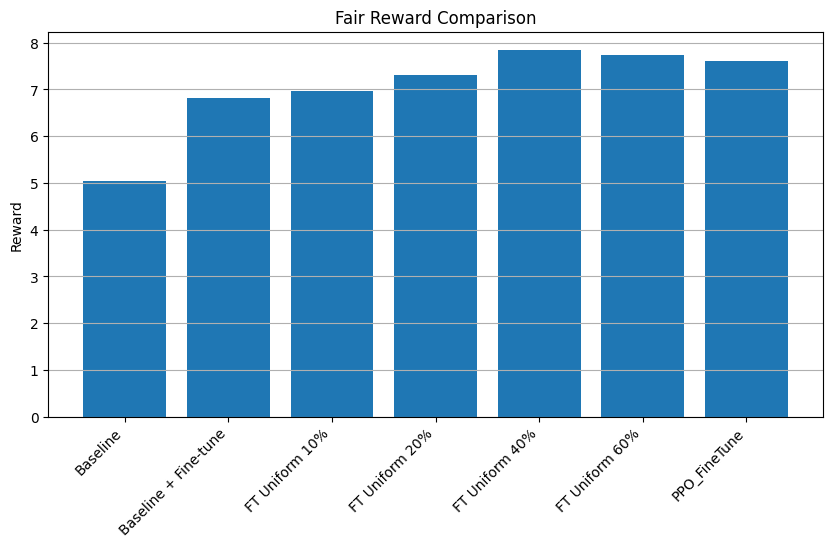

In [52]:
plt.figure(figsize=(10, 5))

plt.bar(final_results_df["Method"], final_results_df["Reward"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Reward")
plt.title("Fair Reward Comparison")
plt.grid(axis="y")
plt.show()